In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [2]:
from core.models import AvarModel, REGISTRY

class ChristieModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "iid_normal_christie"
    param_names = ()

    def _avar(self, sr, T, **kw):
        #return 1.0 + sr**2 / 2.0
        return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.5/T)
    

class MyModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "iid_normal_my"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.75/T)
    
import numpy as np
from scipy.special import gammaln
class ExactAdjModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "exact_adj"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        n = T - 1
        return sr_hat /np.exp(0.5*np.log(n/2) + gammaln((n-1)/2) - gammaln(n/2))
    
class NoAdjModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "no_adj"
    param_names = ()

    def _avar(self, sr, **kw):
        return 1.0 + sr**2 / 2.0

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat
    

        
REGISTRY["christie"] = ChristieModel()
REGISTRY["iid_normal_my"] = MyModel()
#REGISTRY["exact_adj"] = ExactAdjModel()
REGISTRY["no_adj"] = NoAdjModel()


In [6]:
# name : (dgp_names, model_short_names)
scenarios = {
    "christie": (
        ["iid_normal"],
        ["iid_normal_my", "christie", "no_adj"],#, "exact_adj"
    ),
}

In [7]:
N_SIM  = 30_000
N_JOBS = 8

experiments = {
    "christie": ExperimentSpec(
        scenario   = scenarios["christie"],
        param_name = "T",
        param_values = [15, 30, 50, 100, 200],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        bias_adj = True,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

In [8]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        "christie",
    ],
)


  Experiment: christie
  [1/5]  T=15  (TWO_SIDED_COVERAGE)
  [2/5]  T=30  (TWO_SIDED_COVERAGE)
  [3/5]  T=50  (TWO_SIDED_COVERAGE)
  [4/5]  T=100  (TWO_SIDED_COVERAGE)
  [5/5]  T=200  (TWO_SIDED_COVERAGE)


In [9]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)

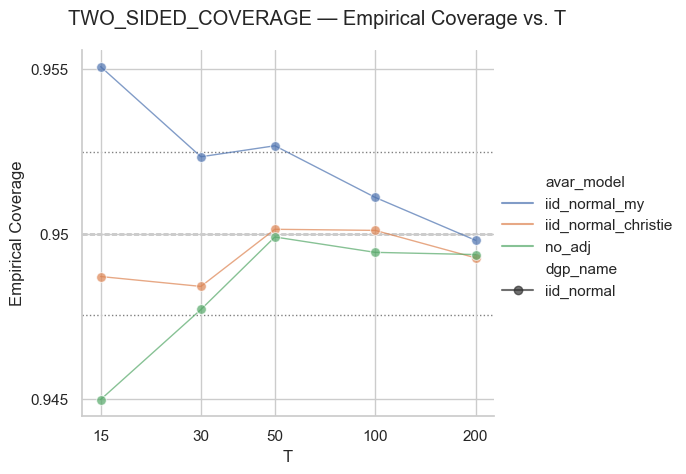

In [11]:
run_analysis(experiments, "christie", alpha=0.05, plot_mask=[0,0,1],
             line_plot_kargs=line_plot_kargs |
             dict(log=True, yticks=[0.945, 0.95, 0.955], xticks=[15, 30, 50, 100, 200]))

In [ ]:
"""
Experimento: Christie (1+1/2T) vs Bao (1+3/4T) vs Corrección Exacta
"""
import numpy as np
from scipy.special import gammaln
import matplotlib.pyplot as plt

MU, SIGMA = 0.5, 2.0
SR_TRUE   = MU / SIGMA
T_GRID    = [20, 30, 50, 100, 200, 500, 1000]
N_SIM     = 200_000
RNG       = np.random.default_rng(42)

def factor_exact(T):
    n = T - 1
    return np.exp(0.5*np.log(n/2) + gammaln((n-1)/2) - gammaln(n/2))

def factor_christie(T): return 1 + 1/(2*T)
def factor_bao(T):      return 1 + 3/(4*T)

T_arr         = np.array(T_GRID)
exact_vals    = np.array([factor_exact(T)    for T in T_GRID])
christie_vals = np.array([factor_christie(T) for T in T_GRID])
bao_vals      = np.array([factor_bao(T)      for T in T_GRID])
delta_chr     = np.abs(exact_vals - christie_vals)
delta_bao     = np.abs(exact_vals - bao_vals)

res_chr, res_bao = [], []
for T in T_GRID:
    X      = RNG.normal(MU, SIGMA, size=(N_SIM, T))
    sr_hat = X.mean(axis=1) / X.std(axis=1, ddof=1)
    res_chr.append(sr_hat.mean() / factor_christie(T) - SR_TRUE)
    res_bao.append(sr_hat.mean() / factor_bao(T)      - SR_TRUE)

res_chr = np.array(res_chr)
res_bao = np.array(res_bao)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Christie (1+1/2T) vs Bao (1+3/4T): convergencia al factor exacto\n"
    f"SR = {SR_TRUE:.2f}  (μ={MU}, σ={SIGMA}),  N_sim={N_SIM:,}",
    fontsize=13)

ax = axes[0]
ax.plot(T_GRID, delta_chr, "o-", color="tab:blue",   label="Christie")
ax.plot(T_GRID, delta_bao, "s-", color="tab:orange", label="Bao")
ax.plot(T_GRID, delta_chr[0]*T_arr[0]/T_arr,    "--", color="tab:blue",   alpha=0.4, label="O(1/T)")
ax.plot(T_GRID, delta_bao[0]*(T_arr[0]/T_arr)**2, "--", color="tab:orange", alpha=0.4, label="O(1/T²)")
ax.set_title("Panel 1 — Analítico\n|factor(T) − exacto(T)|  (log-log)")
ax.set_xlabel("T"); ax.set_ylabel("Error absoluto")
ax.legend(fontsize=8); ax.set_xscale("log"); ax.set_yscale("log")
ax.grid(True, which="both", ls="--", alpha=0.4)

ax = axes[1]
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.plot(T_GRID, res_chr*T_arr, "o-", color="tab:blue",   label="Christie × T")
ax.plot(T_GRID, res_bao*T_arr, "s-", color="tab:orange", label="Bao × T")
ax.set_title("Panel 2 — Simulación\nSesgo residual × T\n(Christie → cte,  Bao → 0)")
ax.set_xlabel("T"); ax.set_ylabel("Sesgo residual × T")
ax.legend(); ax.set_xscale("log")
ax.grid(True, which="both", ls="--", alpha=0.4)

ax = axes[2]
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.plot(T_GRID, res_chr*T_arr**2, "o-", color="tab:blue",   label="Christie × T²")
ax.plot(T_GRID, res_bao*T_arr**2, "s-", color="tab:orange", label="Bao × T²")
ax.set_title("Panel 3 — Simulación\nSesgo residual × T²\n(Bao → cte,  Christie → ∞)")
ax.set_xlabel("T"); ax.set_ylabel("Sesgo residual × T²")
ax.legend(); ax.set_xscale("log")
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.close()

print(f"\n{'T':>6} | {'exacto':>8} | {'Christie':>9} | {'Bao':>8} | {'δ_Chr':>8} | {'δ_Bao':>8} | {'res×T Chr':>10} | {'res×T Bao':>10} | {'res×T² Bao':>11}")
print("-"*100)
for i, T in enumerate(T_GRID):
    print(f"{T:>6} | {exact_vals[i]:>8.5f} | {christie_vals[i]:>9.5f} | {bao_vals[i]:>8.5f} | "
          f"{delta_chr[i]:>8.6f} | {delta_bao[i]:>8.6f} | "
          f"{res_chr[i]*T:>10.4f} | {res_bao[i]*T:>10.4f} | {res_bao[i]*T**2:>11.3f}")



     T |   exacto |  Christie |      Bao |    δ_Chr |    δ_Bao |  res×T Chr |  res×T Bao |  res×T² Bao
----------------------------------------------------------------------------------------------------
    20 |  1.04176 |   1.02500 |  1.03750 | 0.016764 | 0.004264 |     0.0952 |     0.0338 |       0.676
    30 |  1.02683 |   1.01667 |  1.02500 | 0.010159 | 0.001826 |     0.0642 |     0.0027 |       0.080
    50 |  1.01564 |   1.01000 |  1.01500 | 0.005639 | 0.000639 |     0.0538 |    -0.0081 |      -0.403
   100 |  1.00766 |   1.00500 |  1.00750 | 0.002656 | 0.000156 |     0.0862 |     0.0240 |       2.396
   200 |  1.00379 |   1.00250 |  1.00375 | 0.001289 | 0.000039 |     0.1343 |     0.0718 |      14.368
   500 |  1.00151 |   1.00100 |  1.00150 | 0.000506 | 0.000006 |     0.0466 |    -0.0158 |      -7.903
  1000 |  1.00075 |   1.00050 |  1.00075 | 0.000252 | 0.000002 |     0.0667 |     0.0043 |       4.259
